Upgrade the hydroclimate database to the latest structure

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
hydroclimate_database_file = r"D:\imWEBs\test\05_SubareaBasedModel\database\Hydroclimate - Copy.db3"
hydroclimate_database_file = r"C:\Work\imWEBs\test\Hydroclimate - Copy.db3"

In [3]:
sql_change_stations_table_name = """
    ALTER TABLE stations
    RENAME TO stations_old;
"""

sql_create_stations_table = """
    CREATE TABLE IF NOT EXISTS STATIONS (
        ID INTEGER PRIMARY KEY,
        NAME TEXT NOT NULL,
        XPR  REAL,
        YPR  REAL,
        LAT  REAL,
        LONG REAL,
        ELEVATION REAL,
        AREA REAL
    );
    """

sql_create_station_data_table = """
    CREATE TABLE IF NOT EXISTS STATION_DATA_ (
        ID INTEGER PRIMARY KEY,
        STATION INTEGER NOT NULL,
        DATE  TEXT NOT NULL,
        VALUE REAL NOT NULL,
        FOREIGN KEY (STATION) REFERENCES STATIONS (ID)
    );
    """

sql_create_station_data_table_index = """
    CREATE INDEX IDX_STATION_DATA_ ON STATION_DATA_ (STATION);
"""

station_data_tables = [
"STATION_DATA_PCP",
"STATION_DATA_TMX",
"STATION_DATA_TMN",
"STATION_DATA_SLR",
"STATION_DATA_HMD",
"STATION_DATA_WDIR",
"STATION_DATA_WSPD"
]

station_types = {
"P":"PCP",
"TMAX":"TMX",
"TMIN":"TMN",
"RM":"HMD",
"SR":"SLR",
"WS":"WSPD",
"WD":"WDIR"
}

In [4]:
def create_connection(db_file):
    try:
        conn = sqlite3.connect(db_file)
        return conn
    except Exception as e:
        print(e)
        return None

def run_sql(conn, create_table_sql):
    try:
        c = conn.cursor()
        c.execute(create_table_sql)
    except Exception as e:
        print(e)

def populate_stations(conn):
    #populate the new stations table
    query = "SELECT DISTINCT NAME,XPR,YPR,LAT,LONG,ELEVATION,AREA FROM STATIONS_OLD"
    df_stations = pd.read_sql_query(query,conn)
    df_stations["ID"] = df_stations.index + 1
    df_stations.to_sql(f"STATIONS",con = conn, if_exists='append', index=False)

    #populate the station data
    query = "SELECT NAME,TYPE,TABLENAME FROM STATIONS_OLD"
    df_stations_table = pd.read_sql_query(query,conn)
    for index in df_stations_table.index:
        station_name = df_stations_table.loc[index]["NAME"]       
        station_id = df_stations[df_stations["NAME"] == station_name].iloc[0]["ID"]
        data_type = df_stations_table.loc[index]["TYPE"]
        table_name = df_stations_table.loc[index]["TABLENAME"]

        print(f"{station_name} - {data_type} - {table_name}")

        if data_type.upper() not in station_types:
            continue

        query = "SELECT Date, VALUE FROM " + table_name
        df_data = pd.read_sql_query(query,conn)
        df_data["STATION"] = station_id
        df_data.to_sql(f"STATION_DATA_{station_types[data_type.upper()]}",con = conn, if_exists='append',index=False)

        #delete old data table
        run_sql(conn, "DROP TABLE " + table_name)
                
    run_sql(conn, "DROP TABLE stations_old")

In [5]:
conn = create_connection(hydroclimate_database_file)

with conn:
    if conn is not None:
        run_sql(conn, sql_change_stations_table_name)
        run_sql(conn, sql_create_stations_table)

        #create table
        for t in station_data_tables:
            run_sql(conn, sql_create_station_data_table.replace("STATION_DATA_", t))

        #populate data
        populate_stations(conn)

        #create index for station column
        for t in station_data_tables:
            run_sql(conn, sql_create_station_data_table_index.replace("STATION_DATA_", t))

    

JEN_Weather_01 - P - JEN_PCP_02
JEN_Weather_02 - P - JEN_PCP_01
JEN_Weather_03 - P - JEN_PCP_03
JEN_Weather_04 - P - JEN_PCP_04
JEN_Weather_05 - P - JEN_PCP_05
JEN_Weather_06 - P - JEN_PCP_06
JEN_Weather_07 - P - JEN_PCP_07
JEN_Weather_08 - P - JEN_PCP_08
JEN_Weather_09 - P - JEN_PCP_09
JEN_Weather_10 - P - JEN_PCP_10
JEN_Weather_11 - P - JEN_PCP_11
JEN_Weather_12 - P - JEN_PCP_12
JEN_Weather_13 - P - JEN_PCP_13
JEN_Weather_14 - P - JEN_PCP_14
JEN_Weather_01 - TMax - JEN_TMX_01
JEN_Weather_02 - TMax - JEN_TMX_02
JEN_Weather_03 - TMax - JEN_TMX_03
JEN_Weather_04 - TMax - JEN_TMX_04
JEN_Weather_05 - TMax - JEN_TMX_05
JEN_Weather_06 - TMax - JEN_TMX_06
JEN_Weather_07 - TMax - JEN_TMX_07
JEN_Weather_08 - TMax - JEN_TMX_08
JEN_Weather_09 - TMax - JEN_TMX_09
JEN_Weather_10 - TMax - JEN_TMX_10
JEN_Weather_11 - TMax - JEN_TMX_11
JEN_Weather_12 - TMax - JEN_TMX_12
JEN_Weather_13 - TMax - JEN_TMX_13
JEN_Weather_14 - TMax - JEN_TMX_14
JEN_Weather_01 - TMin - JEN_TMN_01
JEN_Weather_02 - TMin - JEN

<Axes: xlabel='DATE'>

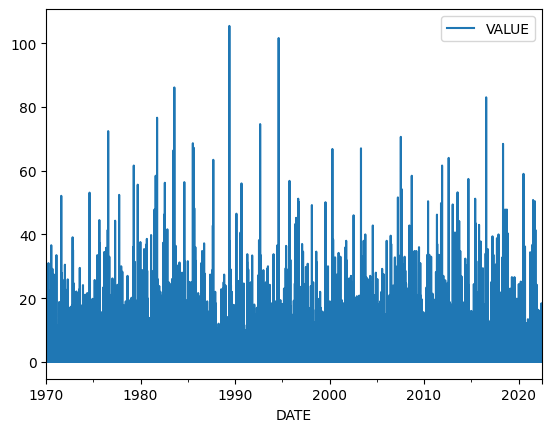

In [6]:
query = "SELECT DATE, VALUE FROM STATION_DATA_PCP where STATION=1" 
df_stations_data = pd.read_sql_query(query,conn, parse_dates=["DATE"], index_col="DATE")
df_stations_data.plot()